<a href="https://colab.research.google.com/github/shriyashshitole/simple-ARIMA/blob/main/ARIMAv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pmdarima as pm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
# ==========================================
# 1. SETTINGS & LOGGING
# ==========================================
TICKER = "AAPL"
MARKET_TICKER = "^GSPC"
PERIOD = "5y"
PREDICTION_DAYS = 30

print(f"--- STEP 1: DATA LOGGING ---")
# Download with auto_adjust=True to avoid the warning
stock_df = yf.download(TICKER, period=PERIOD, progress=False, auto_adjust=True)
market_df = yf.download(MARKET_TICKER, period=PERIOD, progress=False, auto_adjust=True)

# Align data
combined = pd.merge(stock_df['Close'], market_df['Close'], left_index=True, right_index=True, suffixes=('', '_Market'))
combined.columns = ['Close', 'Market']
combined = combined.dropna()

# Clean indices
y = combined['Close'].copy()
y.index = pd.to_datetime(y.index).tz_localize(None)
exo = combined['Market'].copy()
exo.index = pd.to_datetime(exo.index).tz_localize(None)

print(f"Rows of data retrieved: {len(y)}")
print(f"Data start date: {y.index[0].date()}")
print(f"Data end date:   {y.index[-1].date()}")
print(f"Last Price:      ${y.iloc[-1]:.2f}")

--- STEP 1: DATA LOGGING ---
Rows of data retrieved: 1256
Data start date: 2021-02-08
Data end date:   2026-02-06
Last Price:      $279.25


In [ ]:
# ==========================================
# 2. TRAINING THE MODEL
# ==========================================
print("\n--- STEP 2: TRAINING SARIMAX (Deep Search) ---")

# Stepwise search for best parameters
stepwise_model = pm.auto_arima(y,
                              exogenous=exo.values.reshape(-1, 1),
                              seasonal=True, m=5,
                              d=1,
                              trace=True,
                              error_action='ignore',
                              suppress_warnings=True)

print(f"Best Model Order: {stepwise_model.order}")

# Fit the final model using statsmodels for advanced simulation
final_model = SARIMAX(y,
                      exog=exo,
                      order=stepwise_model.order,
                      seasonal_order=stepwise_model.seasonal_order).fit(disp=False)


--- STEP 2: TRAINING SARIMAX (Deep Search) ---
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[5] intercept   : AIC=6406.811, Time=4.48 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=6405.502, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=6406.093, Time=0.39 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=6406.143, Time=0.40 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=6405.262, Time=0.05 sec
 ARIMA(0,1,0)(1,0,0)[5] intercept   : AIC=6406.793, Time=0.21 sec
 ARIMA(0,1,0)(0,0,1)[5] intercept   : AIC=6406.714, Time=0.43 sec
 ARIMA(0,1,0)(1,0,1)[5] intercept   : AIC=6407.425, Time=1.69 sec
 ARIMA(1,1,0)(0,0,0)[5] intercept   : AIC=6404.734, Time=0.31 sec
 ARIMA(1,1,0)(0,0,1)[5] intercept   : AIC=6406.019, Time=0.73 sec
 ARIMA(1,1,0)(1,0,1)[5] intercept   : AIC=6406.770, Time=1.03 sec
 ARIMA(2,1,0)(0,0,0)[5] intercept   : AIC=6406.069, Time=0.28 sec
 ARIMA(1,1,1)(0,0,0)[5] intercept   : AIC=6406.525, Time=0.40 sec
 ARIMA(0,1,1)(0,0,0)[5] intercept   : AIC=6404.872,

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
# ==========================================
# 3. FORECASTING & SIMULATION
# ==========================================
print("\n--- STEP 3: GENERATING VARIATION ---")

# Setup future dates
last_date = y.index[-1]
future_dates = pd.date_range(start=last_date, periods=PREDICTION_DAYS + 1, freq='B')[1:]

# Create a "Market Forecast" (assuming it grows at its historical average)
avg_market_growth = exo.pct_change().mean()
future_market_vals = [exo.iloc[-1] * (1 + avg_market_growth)**i for i in range(1, PREDICTION_DAYS + 1)]
future_exo = pd.DataFrame(future_market_vals, index=future_dates, columns=['Market'])

# 1. Get Mean Forecast
forecast_res = final_model.get_forecast(steps=PREDICTION_DAYS, exog=future_exo)
mean_forecast = forecast_res.predicted_mean
conf_int = forecast_res.conf_int()

# 2. Get 10 Simulated "Wiggly" Paths
# FIX: Wrap the numpy output of .simulate into a DataFrame
sim_array = final_model.simulate(nsimulations=PREDICTION_DAYS, anchor='end', repetitions=10, exog=future_exo)
sims = pd.DataFrame(sim_array, index=future_dates)


--- STEP 3: GENERATING VARIATION ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


InvalidIndexError: (slice(None, None, None), 0)

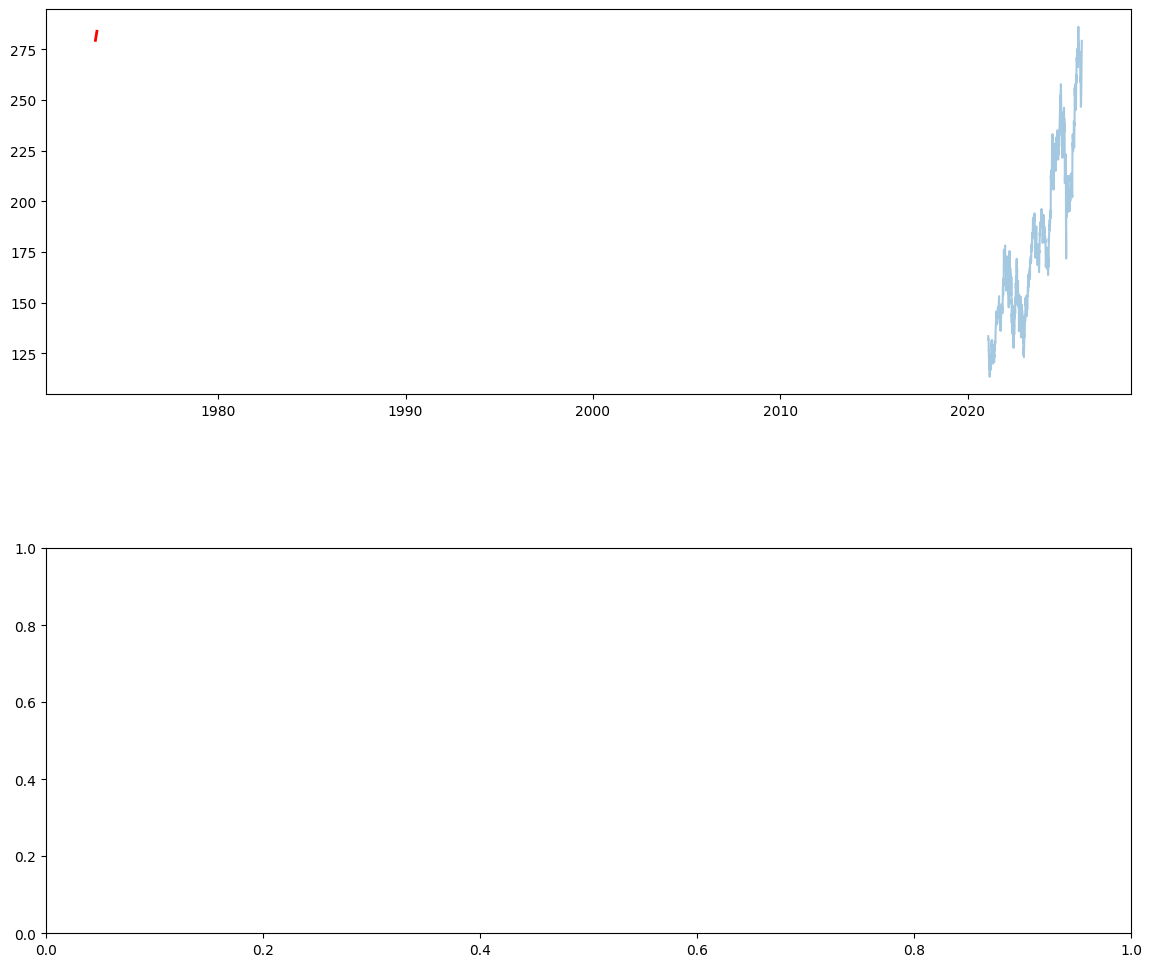

In [ ]:
# ==========================================
# 4. TWO-PART VISUALIZATION
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
plt.subplots_adjust(hspace=0.4)

# PLOT 1: Full 5-Year Context
ax1.plot(y.index, y, label="Historical Price", color='#1f77b4', alpha=0.4)
ax1.plot(mean_forecast.index, mean_forecast, label="Average Forecast", color='red', linewidth=2)
ax1.fill_between(future_dates, conf_int[:, 0], conf_int[:, 1], color='red', alpha=0.1)
ax1.set_title(f"Visual 1: {TICKER} 5-Year History and Predicted Trend")
ax1.legend()
ax1.grid(True, alpha=0.2)

# PLOT 2: Day-Wise Zoom (Last 30 days + Future 30 days)
history_zoom = y.tail(30)
ax2.plot(history_zoom.index, history_zoom, label="Actual (Last 30 Days)", color='#1f77b4', marker='o', linewidth=2)
ax2.plot(mean_forecast.index, mean_forecast, label="Average Forecast", color='red', linestyle='--', marker='s', alpha=0.7)

# Plot the Simulations (The Zig-Zags)
for i in range(sims.shape[1]):
    ax2.plot(sims.index, sims.iloc[:, i], color='gray', alpha=0.3, linewidth=1, label="Simulated Reality" if i==0 else "")

ax2.set_title(f"Visual 2: Day-Wise Forecast for the next {PREDICTION_DAYS} days")
ax2.set_ylabel("Price (USD)")
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.show()

print(f"Forecast for {mean_forecast.index[-1].date()}: ${mean_forecast.iloc[-1]:.2f}")